In [1]:
from moabb.paradigms import MotorImagery, LeftRightImagery
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

sfreq=250

paradigm=LeftRightImagery(resample=sfreq)
datasets = [
    BNCI2014_004(),
]


In [2]:
from sklearn.pipeline import make_pipeline, Pipeline
from hoda.hoda import HODA, BTTDA,  GreedyBTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import ToeplitzLDAWrapper,ZScore
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
from sklearn.linear_model import LogisticRegression
from hoda.tensorize import  Vectorize, Tensorize
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from hoda.classification import SelectF
import tensorly as tl

pipelines=dict()

cv=StratifiedKFold(random_state=42, shuffle=True)


hoda_params = dict(
    max_iter=64,
    tol=1e-8,
    init ='random',
    random_state=42,
    shrinkage='lw',
    solver='lanczos',
    taper=False,
    forward=False,
    obj='tr',
    toeplitz=None,
    delta=None,
    extra_train_info=False,
)

bttda_params=dict(
        truncate=True,
        n_jobs=1,
        hoda_params=hoda_params,
        extra_train_info=False,
        verbose=False,
        cv=cv,
)


clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LDA(shrinkage='auto', solver='lsqr')
)

pipelines['HODA'] = Pipeline([
    ('bttda', GreedyBTTDA(
        max_blocks=1,
        **bttda_params,
        clf=clf,
    )),
    ('clf', clf)
])

pipelines['BTTDA_4'] = Pipeline([
    ('bttda', GreedyBTTDA(
        max_blocks=4,
        **bttda_params,
        clf=clf,
    )),
    ('clf', clf)
])
"""
pipelines['PARAFACDA_4'] = Pipeline([
    ('bttda', GreedyBTTDA(
        max_blocks=4,
        **bttda_params,
        clf=clf,
        rank_grid=[1],
    )),
    ('clf', clf)
])
"""

"\npipelines['PARAFACDA_4'] = Pipeline([\n    ('bttda', GreedyBTTDA(\n        max_blocks=4,\n        **bttda_params,\n        clf=clf,\n        rank_grid=[1],\n    )),\n    ('clf', clf)\n])\n"

In [3]:
import pandas as pd
from sklearn.preprocessing import FunctionTransformer
from hoda.tensorize import stf_tensor

post_pipe = FunctionTransformer(stf_tensor, kw_args=dict(sfreq=sfreq, zscore=False))
results = []
for dataset in datasets:
    print(dataset.code)
    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=False,
        random_state=42,
        n_jobs=5,
        suffix=f'bttda_{dataset.code}',
    )
    results.append(evaluation.process(pipelines,postprocess_pipeline=post_pipe))
results = pd.concat(results)

BNCI2014-004


BNCI2014-004-WithinSession:   0%|          | 0/9 [00:00<?, ?it/s]/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/si

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-004-WithinSession:  11%|█         | 1/9 [11:42<1:33:39, 702.42s/it]/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/py

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


...

BNCI2014-004-WithinSession:  78%|███████▊  | 7/9 [1:21:01<22:35, 677.57s/it]/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/py

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-004-WithinSession:  89%|████████▉ | 8/9 [1:32:53<11:28, 688.59s/it]/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/py

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-004-WithinSession: 100%|██████████| 9/9 [1:44:11<00:00, 694.58s/it]


In [4]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.854167,4.359582,120.0,1,0train,3,5,BNCI2014-004,HODA
1,0.727778,4.416224,120.0,1,1train,3,5,BNCI2014-004,HODA
2,0.839844,4.714311,160.0,1,2train,3,5,BNCI2014-004,HODA
3,0.892969,4.744414,160.0,1,3test,3,5,BNCI2014-004,HODA
4,0.809375,5.193418,160.0,1,4test,3,5,BNCI2014-004,HODA
...,...,...,...,...,...,...,...,...,...
85,0.777778,15.998559,120.0,9,0train,3,5,BNCI2014-004,BTTDA_4
86,0.590278,23.271339,120.0,9,1train,3,5,BNCI2014-004,BTTDA_4
87,0.917969,23.630920,160.0,9,2train,3,5,BNCI2014-004,BTTDA_4
88,0.925781,22.801735,160.0,9,3test,3,5,BNCI2014-004,BTTDA_4


In [5]:
results.to_csv('moabb_results_mi.csv')

In [6]:
results.groupby(['dataset','session', 'pipeline'])['score'].aggregate('mean') 

dataset       session  pipeline
BNCI2014-004  0train   BTTDA_4     0.703887
                       HODA        0.728530
              1train   BTTDA_4     0.711190
                       HODA        0.701153
              2train   BTTDA_4     0.848698
                       HODA        0.847917
              3test    BTTDA_4     0.820177
                       HODA        0.837577
              4test    BTTDA_4     0.803559
                       HODA        0.831771
Name: score, dtype: float32

In [7]:
results.groupby(['dataset','session', 'pipeline'])['score'].aggregate('std') 

dataset       session  pipeline
BNCI2014-004  0train   BTTDA_4     0.162553
                       HODA        0.159218
              1train   BTTDA_4     0.179762
                       HODA        0.192993
              2train   BTTDA_4     0.159570
                       HODA        0.168741
              3test    BTTDA_4     0.186137
                       HODA        0.178994
              4test    BTTDA_4     0.201269
                       HODA        0.194772
Name: score, dtype: float64

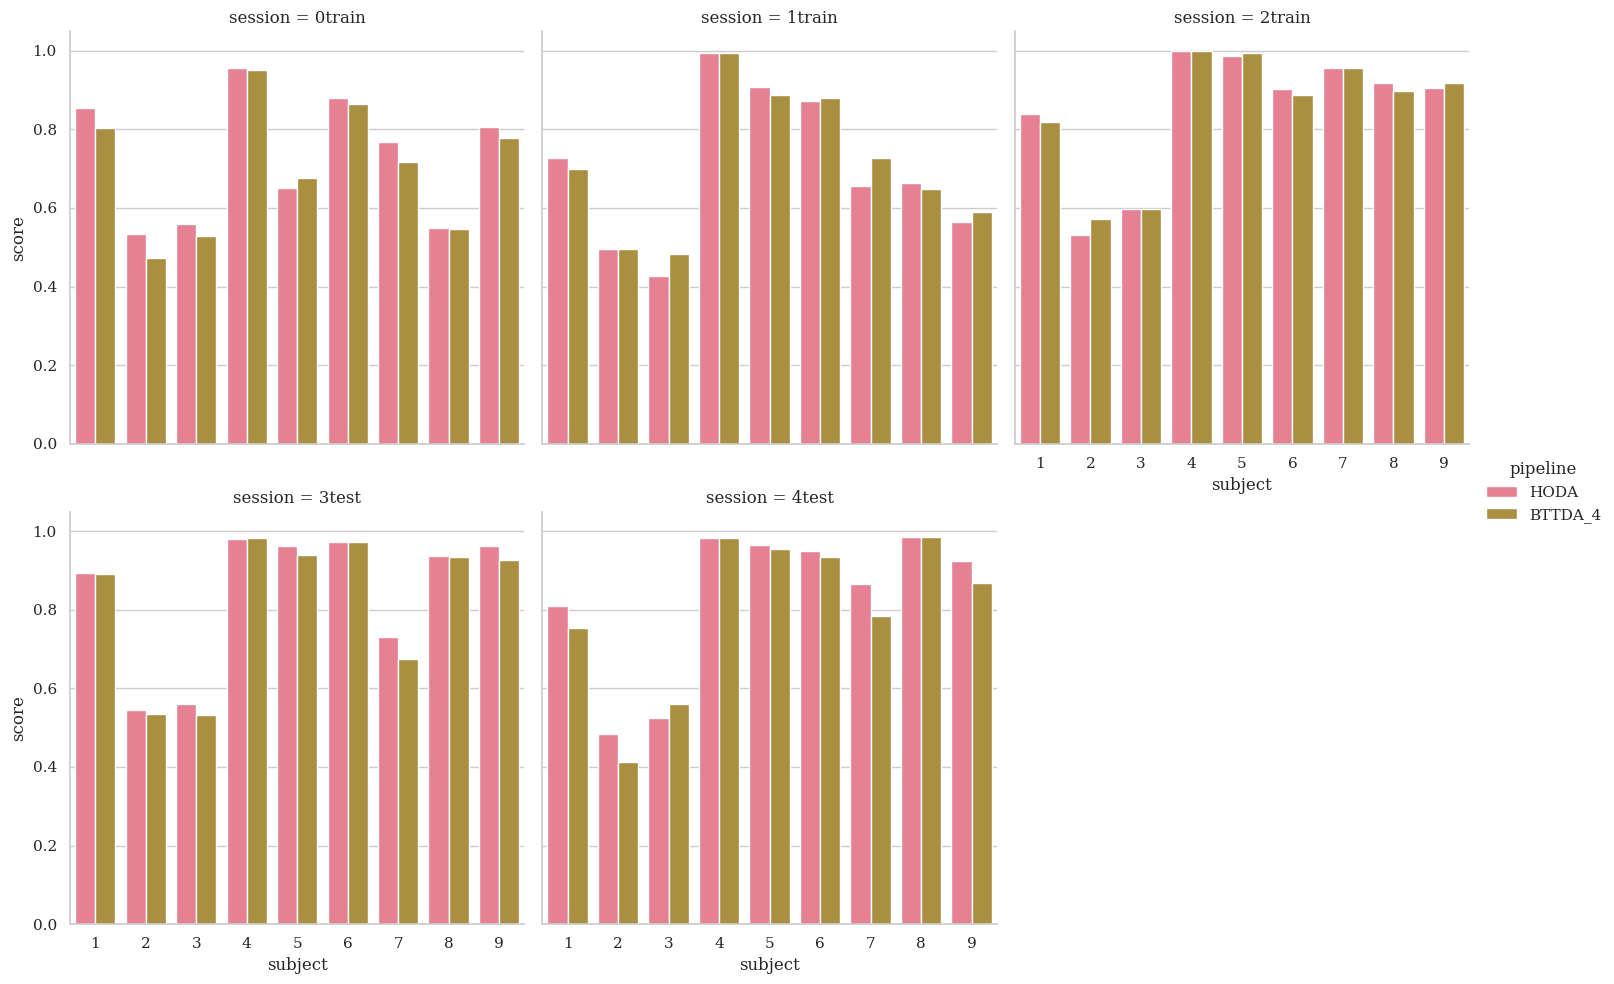

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()


sns.catplot(data=results , col='session',x='subject', y='score',hue='pipeline', col_wrap=3,kind='bar')
plt.show()

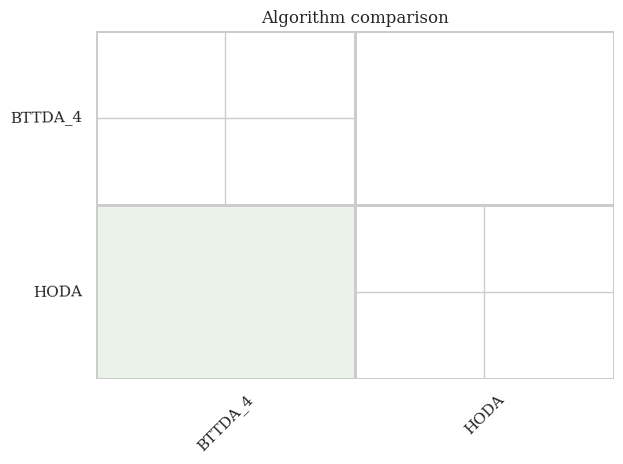

In [9]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)
plt.show()

KeyError: 'BTTDA_10'

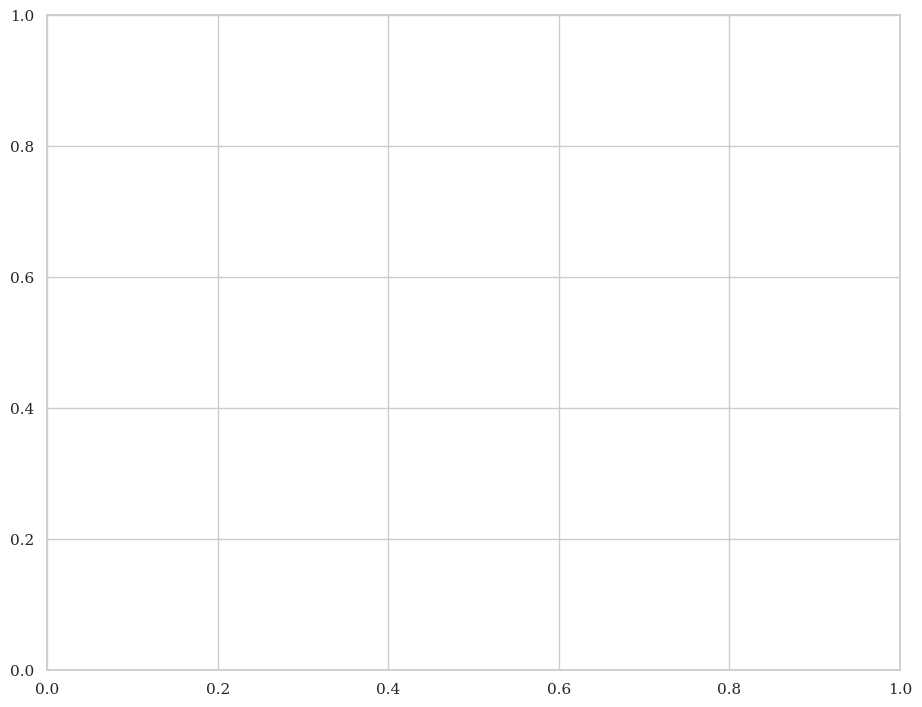

In [10]:
import moabb.analysis.plotting as moabb_plt
fig = moabb_plt.paired_plot(results, "BTTDA_10", "HODA")
plt.show()